In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from scipy.interpolate import CubicSpline

sns.set_style("whitegrid")

In [31]:
df_full = pd.read_csv("processed-data/2023/processed_2023_qc.csv")
df_full["date"] = pd.to_datetime(df_full["date"])

In [32]:
df = df_full[["date", 
              "time", 
              "Air Temperature in degree C"]]

df = df.rename(columns={"Air Temperature in degree C": "temp(c)"})

df["hour"] = np.arange(df.shape[0]) # Column representing hour of YEAR

# Ensure the time column is numeric and in the correct format
df["time"] = pd.to_datetime(df["time"], format="%H:%M:%S").dt.hour
df["time"] = pd.to_numeric(df["time"])

df.head(5)

,date,time,temp(c),hour
0,2023-01-01,0,16.0,0
1,2023-01-01,1,16.0,1
2,2023-01-01,2,15.7,2
3,2023-01-01,3,15.2,3
4,2023-01-01,4,15.0,4


# Section 1 - Air temperature interpolation for modelling

The sampled winter and summer days for interpolations were chosen as:
##### Winter - 10/01/2023, Summer - 11/07/2023

To reach the stability criterion, the hourly air temperature data had to be split into 10, 6 minute time steps.

In [33]:
df_day_temp = df[["date", "time", "temp(c)"]]

df_wnt_day = df_day_temp[df_day_temp["date"] == "2023-01-10"]
df_sum_day = df_day_temp[df_day_temp["date"] == "2023-07-11"]

df_wnt_day = df_wnt_day.drop(columns=["date"])
df_sum_day = df_sum_day.drop(columns=["date"])

#### Try Linear Interpolation for Winter Day

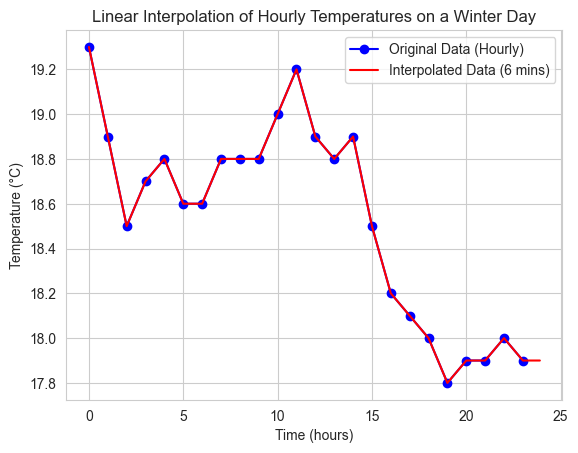

In [34]:
# Create linear interpolator

new_time = np.arange(df_wnt_day["time"].min(), df_wnt_day["time"].max() + 1, 1/10)  # 1/10 for 10 time steps per hour

# Perform linear interpolation
df_interpolated = pd.DataFrame({"time": new_time})
df_interpolated["temp(c)"] = np.interp(new_time, df_wnt_day["time"], df_wnt_day["temp(c)"])

# Plot the original data and the interpolated data
plt.plot(df_wnt_day["time"], df_wnt_day["temp(c)"], "o-", label="Original Data (Hourly)", color="blue")
plt.plot(df_interpolated["time"], df_interpolated["temp(c)"], "-", label="Interpolated Data (6 mins)", color="red")

# Add labels and legend
plt.title("Linear Interpolation of Hourly Temperatures on a Winter Day")
plt.xlabel("Time (hours)")
plt.ylabel("Temperature (°C)")
plt.legend()

# Show the plot
plt.grid(True)
plt.show()

#### Try Cubic Spline Interpolation for Winter Day

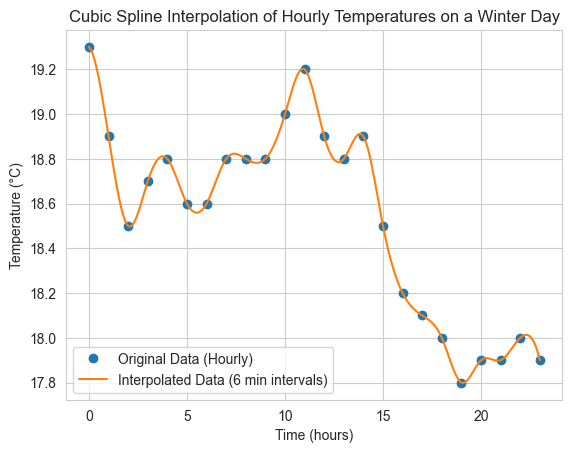

In [35]:
# Create cubic spline interpolator

cs = CubicSpline(df_wnt_day["time"], df_wnt_day["temp(c)"])

new_time = np.linspace(df_wnt_day["time"].min(), df_wnt_day["time"].max(), 24*10)  # 24 hours with 10 time steps each: 24 * 10

# Interpolate the temperature at these new time points
interpolated_temps = cs(new_time)
interpolated_temps = np.round(interpolated_temps, 10)

# Create a DataFrame for better visualization
df_interpolated_wnt = pd.DataFrame({
    "time": new_time,
    "temp_w(c)": interpolated_temps
})

# Plot the original data and the interpolated data
plt.plot(df_wnt_day["time"], df_wnt_day["temp(c)"], "o", label="Original Data (Hourly)")
plt.plot(df_interpolated_wnt["time"], df_interpolated_wnt["temp_w(c)"], "-", label="Interpolated Data (6 min intervals)")
plt.title("Cubic Spline Interpolation of Hourly Temperatures on a Winter Day")
plt.xlabel("Time (hours)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

df_interpolated_wnt.to_csv("processed-data/20230110_interpolated.csv", index=False)

#### Cubic Spline interpolation was chosen as it was deemed more accurate for short term hourly temperature interpolation [[Source]](https://apps.dtic.mil/sti/tr/pdf/ADA240489.pdf)

#### Now applying cubic spline interpolation to the sampled summer day:

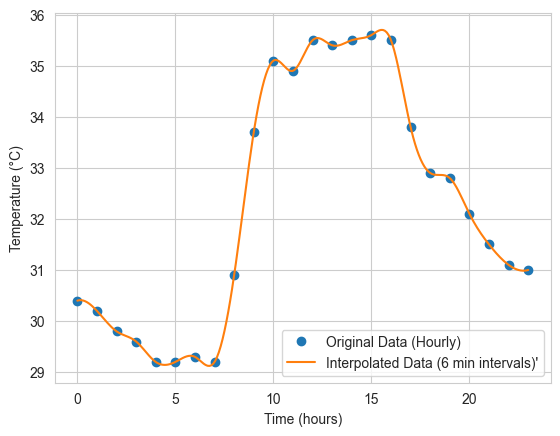

In [36]:
# Apply cubic spline interpolator to summer data

cs_sum = CubicSpline(df_sum_day["time"], df_sum_day["temp(c)"])

new_time = np.linspace(df_sum_day["time"].min(), df_sum_day["time"].max(), 24 * 10)  # 24 hours with 10 time steps each: 24 * 10

# Interpolate the temperature at these new time points
interpolated_temps = cs_sum(new_time)
# Round to 10dp
interpolated_temps = np.round(interpolated_temps, 10)

# Create a DataFrame for better visualization
df_interpolated_sum = pd.DataFrame({
    "time": new_time,
    "temp_s(c)": interpolated_temps
})


# Plot the original data and the interpolated data
plt.plot(df_sum_day["time"], df_sum_day["temp(c)"], "o", label="Original Data (Hourly)")
plt.plot(df_interpolated_sum["time"], df_interpolated_sum["temp_s(c)"], "-", label="Interpolated Data (6 min intervals)'")
plt.xlabel("Time (hours)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(True)
plt.show()

df_interpolated_sum.to_csv("processed-data/20230711_interpolated.csv", index=False)

# Section 2 - Determining the Average Hourly Air Temperatures for the Winter and Summer Months

For the modelling section of the coursework, an initial internal temperature of the wall analysed was required. To find a representative internal temperature distribution, a series of simulations were run using the mean hourly temperatures for both seasons.

The mean hourly temperatures for both seasons was found below and exported into a csv file.

In [37]:
df_summer = df[(df["date"] >= "2023-06-01") & (df["date"] < "2023-09-01")].copy()
df_winter = df[ (df["date"] < "2023-03-01") |
               (df["date"] >= "2023-12-01")].copy()

df_winter_avg = df_winter[["time", "temp(c)"]].copy()

df_winter_avg_hr = df_winter_avg.groupby("time")["temp(c)"].mean().reset_index()

cs_wnt_hr = CubicSpline(df_winter_avg_hr["time"], df_winter_avg_hr["temp(c)"])

new_time = np.linspace(df_winter_avg_hr["time"].min(), df_winter_avg_hr["time"].max(), 24 * 10)  # 24 hours with 10 time steps each: 24 * 10

# Interpolate the temperature at these new time points
interpolated_temps = cs_wnt_hr(new_time)
# Round to 10dp
interpolated_temps = np.round(interpolated_temps, 10)

# Create a DataFrame for better visualisation
df_interpolated_wnt_hr = pd.DataFrame({
    "time": new_time,
    "temp(c)": interpolated_temps
})

df_interpolated_wnt_hr.to_csv("processed-data/2023_winter_avg_hr.csv", index=False)

# Summer

df_summer_avg = df_summer[["time", "temp(c)"]].copy()

df_summer_avg_hr = df_summer_avg.groupby("time")["temp(c)"].mean().reset_index()

cs_sum_hr = CubicSpline(df_summer_avg_hr["time"], df_summer_avg_hr["temp(c)"])

new_time = np.linspace(df_summer_avg_hr["time"].min(), df_summer_avg_hr["time"].max(), 24 * 10)  # 24 hours with 10 time steps each: 24 * 10

# Interpolate the temperature at these new time points
interpolated_temps = cs_sum_hr(new_time)
# Round to 10dp
interpolated_temps = np.round(interpolated_temps, 10)

df_interpolated_sum_hr = pd.DataFrame({
    "time": new_time,
    "temp(c)": interpolated_temps
})

df_interpolated_sum_hr.to_csv("processed-data/2023_summer_avg_hr.csv", index=False)

# Section 3 - Post-Processing Results

The heat flow through the external wall of the chosen system was modelled for a day in the winter (10/01/2023) and a summer day (11/07/2023).

The energy flow and heat flux from the results of both models are plotted below, and were used in the coursework.

### Loading the results

In [38]:
df_results = pd.read_csv("processed-data/2023_sum_win_results.csv", encoding="utf-8")

df_results = df_results.rename(columns={"time (s)": "time"})

df_results["energy_flow_w(Wh/m^2)"] = df_results["heat_flux_w(W/m^2)"] * 0.1 
df_results["cumulative_energy_w"] = df_results["energy_flow_w(Wh/m^2)"].cumsum()

df_results["energy_flow_s(Wh/m^2)"] = df_results["heat_flux_s(W/m^2)"] * 0.1  
df_results["cumulative_energy_s"] = df_results["energy_flow_s(Wh/m^2)"].cumsum()

df_results = df_results.merge(df_interpolated_wnt[["temp_w(c)"]], left_index=True, right_index=True)
df_results = df_results.merge(df_interpolated_sum[["temp_s(c)"]], left_index=True, right_index=True)

df_results.head(5)

,time,heat_flux_w(W/m^2),energy_flow_w(kJ/m^2),heat_flux_s(W/m^2),energy_flow_s(kJ/m^2),energy_flow_w(Wh/m^2),cumulative_energy_w,energy_flow_s(Wh/m^2),cumulative_energy_s,temp_w(c),temp_s(c)
0,0,-3.559095,-1.281274,10.225599,3.681216,-0.355909,-0.355909,1.022560,1.022560,19.300000,30.400000
1,360,-3.564551,-1.283238,10.212690,3.676568,-0.356455,-0.712365,1.021269,2.043829,19.288246,30.408754
2,720,-3.570282,-1.285302,10.199438,3.671798,-0.357028,-1.069393,1.019944,3.063773,19.268381,30.409801
3,1080,-3.576277,-1.287460,10.185863,3.666910,-0.357628,-1.427021,1.018586,4.082359,19.241271,30.403765
4,1440,-3.582527,-1.289710,10.171980,3.661913,-0.358253,-1.785273,1.017198,5.099557,19.207777,30.391269


#### Processing results from the winter day (10/01/2023)

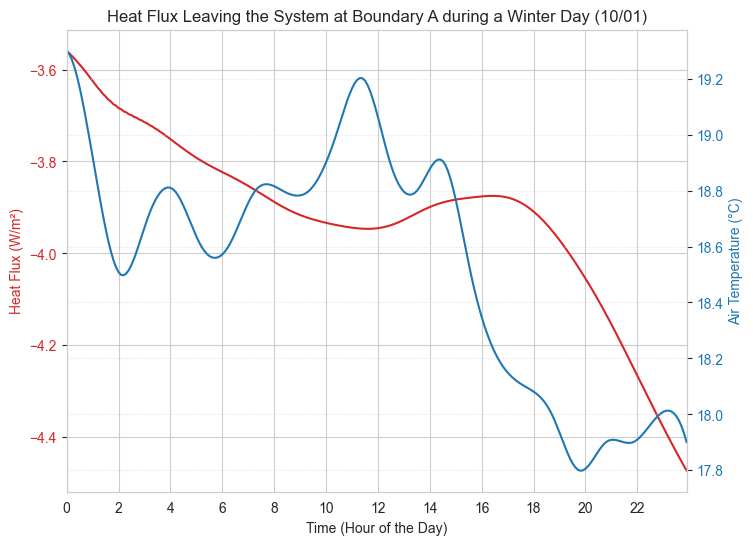

In [39]:
# Plot heat flux on primary y-axis
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(df_results["time"], df_results["heat_flux_w(W/m^2)"], label="Heat Flux", color="tab:red")
ax1.set_xlabel("Time (Hour of the Day)")
ax1.set_ylabel("Heat Flux (W/m²)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

# Create secondary y-axis for air temperature
ax2 = ax1.twinx()
ax2.plot(df_results["time"], df_results["temp_w(c)"], label="Air Temperature", color="tab:blue")
ax2.set_ylabel("Air Temperature (°C)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Set title
plt.title("Heat Flux Leaving the System at Boundary A during a Winter Day (10/01)")

# Set x-axis ticks (convert time from seconds to hours)
tick_positions = [i * 3600 for i in range(0, 25, 2)] 
tick_labels = range(0, 25, 2) 
ax1.set_xticks(tick_positions) 
ax1.set_xticklabels(tick_labels)

# Set x-axis limits to match the data range (removes left/right gaps)
plt.xlim(df_results["time"].min(), df_results["time"].max())

# Synchronize y-ticks spacing

# Grid and layout adjustments
ax2.grid(True, linestyle="dotted", alpha=0.6)

plt.savefig("output-graphs/model/heat_flux_winter.png", dpi=1000)

plt.show()

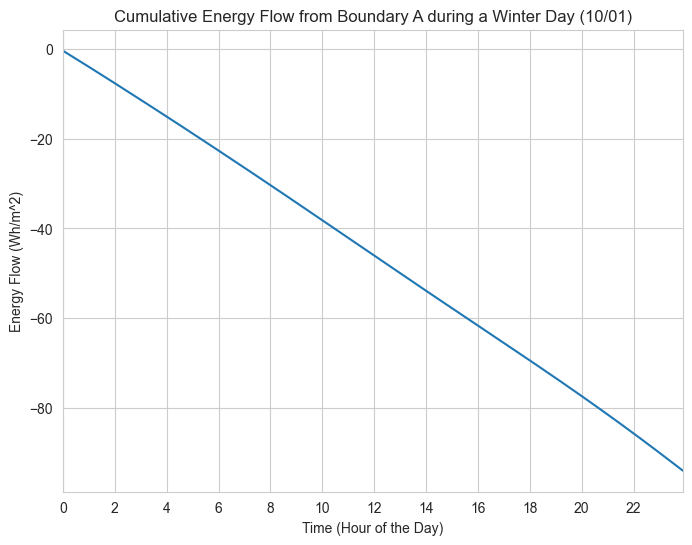

In [40]:
plt.figure(figsize=(8, 6))

sns.lineplot(x="time", y="cumulative_energy_w", data=df_results)
plt.title("Cumulative Energy Flow from Boundary A during a Winter Day (10/01)")
plt.ylabel("Energy Flow (Wh/m^2)")
plt.xlabel("Time (Hour of the Day)")

tick_positions = [i * 3600 for i in range(0, 25, 2)]  # Convert hours to seconds
tick_labels = range(0, 25, 2)  # Labels remain in hours

plt.xticks(tick_positions, tick_labels)

# Set x-axis limits to match the data range (removes left/right gaps)
plt.xlim(df_results["time"].min(), df_results["time"].max())

plt.savefig("output-graphs/model/energy_flow_winter.png", dpi=1000)

plt.show()

#### Processing results from the summer day (11/07/2023)

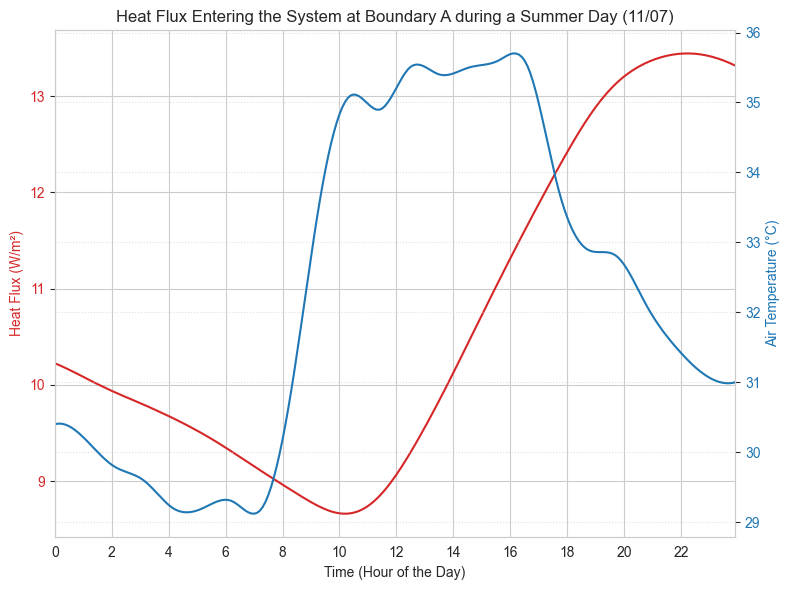

In [41]:
# Plot heat flux on primary y-axis
fig, ax1 = plt.subplots(figsize=(8, 6))
ax1.plot(df_results["time"], df_results["heat_flux_s(W/m^2)"], label="Heat Flux", color="tab:red")
ax1.set_xlabel("Time (Hour of the Day)")
ax1.set_ylabel("Heat Flux (W/m²)", color="tab:red")
ax1.tick_params(axis="y", labelcolor="tab:red")

# Create secondary y-axis for air temperature
ax2 = ax1.twinx()
ax2.plot(df_results["time"], df_results["temp_s(c)"], label="Air Temperature", color="tab:blue")
ax2.set_ylabel("Air Temperature (°C)", color="tab:blue")
ax2.tick_params(axis="y", labelcolor="tab:blue")

# Set title
plt.title("Heat Flux Entering the System at Boundary A during a Summer Day (11/07)")

# Set x-axis ticks (convert time from seconds to hours)
tick_positions = [i * 3600 for i in range(0, 25, 2)] 
tick_labels = range(0, 25, 2) 
ax1.set_xticks(tick_positions) 
ax1.set_xticklabels(tick_labels)

# Set x-axis limits to match the data range (removes left/right gaps)
plt.xlim(df_results["time"].min(), df_results["time"].max())

# Synchronize y-ticks spacing

# Grid and layout adjustments
ax2.grid(True, linestyle="dotted", alpha=0.6)
fig.tight_layout()
plt.savefig("output-graphs/model/heat_flux_summer.png", dpi=1000)

plt.show()

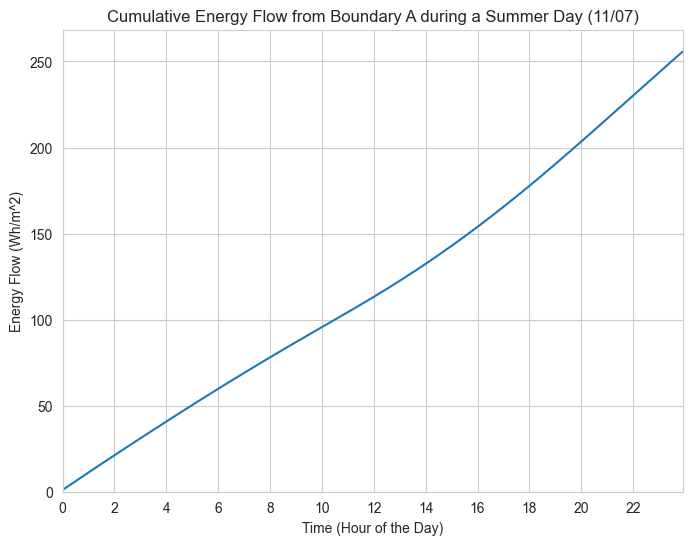

In [42]:
plt.figure(figsize=(8, 6))

sns.lineplot(x="time", y="cumulative_energy_s", data=df_results)
plt.title("Cumulative Energy Flow from Boundary A during a Summer Day (11/07)")
plt.ylabel("Energy Flow (Wh/m^2)")
plt.xlabel("Time (Hour of the Day)")

tick_positions = [i * 3600 for i in range(0, 25, 2)]  # Convert hours to seconds
tick_labels = range(0, 25, 2)  # Labels remain in hours

plt.xticks(tick_positions, tick_labels)

# Set x-axis limits to match the data range (removes left/right gaps)
plt.xlim(df_results["time"].min(), df_results["time"].max())
plt.ylim(0,)

plt.savefig("output-graphs/model/energy_flow_summer.png", dpi=1000)

plt.show()